# Aave V2 Wallet Credit Scoring System

This notebook implements a machine learning model to assign credit scores to wallets based on their transaction behavior in the Aave V2 protocol. The scores range from 0 to 1000, where higher scores indicate more reliable and responsible usage patterns.

# Import Required Libraries

Import necessary libraries for data processing, machine learning, and visualization.

In [22]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# JSON handling
import json

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualizations
plt.style.use('seaborn-v0_8')  # Updated style name for compatibility
sns.set_theme(style="whitegrid")

# Load and Inspect Transaction Data

Load the transaction data from JSON file and inspect its structure.

In [23]:
# Load the transaction data
with open('user-wallet-transactions.json', 'r') as file:
    data = json.load(file)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display basic information about the dataset
print("Dataset Info:")
print("-" * 50)
print(df.info())
print("\nSample Records:")
print("-" * 50)
print(df.head())
print("\nUnique Actions:")
print("-" * 50)
print(df['action'].unique())
print("\nBasic Statistics:")
print("-" * 50)
print(df.describe())

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   _id          100000 non-null  object
 1   userWallet   100000 non-null  object
 2   network      100000 non-null  object
 3   protocol     100000 non-null  object
 4   txHash       100000 non-null  object
 5   logId        100000 non-null  object
 6   timestamp    100000 non-null  int64 
 7   blockNumber  100000 non-null  int64 
 8   action       100000 non-null  object
 9   actionData   100000 non-null  object
 10  __v          100000 non-null  int64 
 11  createdAt    100000 non-null  object
 12  updatedAt    100000 non-null  object
dtypes: int64(3), object(10)
memory usage: 9.9+ MB
None

Sample Records:
--------------------------------------------------
                                    _id  \
0  {'$oid': '681d38fed63812d

# Feature Engineering from Transaction Data

Extract and engineer features from the transaction data that might indicate wallet reliability and behavior patterns.

In [24]:
def engineer_features(df):
    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
    # Extract amount from actionData and convert to float
    df['amount'] = df['actionData'].apply(lambda x: float(x.get('amount', 0)))
    # Group by userWallet address
    wallet_features = {}
    for wallet in df['userWallet'].unique():
        wallet_data = df[df['userWallet'] == wallet]
        # Basic transaction counts
        total_transactions = len(wallet_data)
        # Action type ratios
        action_counts = wallet_data['action'].value_counts()
        total_actions = len(wallet_data)
        action_ratios = {
            f"{action}_ratio": count/total_actions 
            for action, count in action_counts.items()
        }
        # Amount-based features
        amount_stats = wallet_data['amount'].describe()
        # Time-based features
        time_diff = wallet_data['timestamp'].max() - wallet_data['timestamp'].min()
        avg_time_between_txns = time_diff.total_seconds() / total_transactions if total_transactions > 1 else 0
        # Risk indicators
        liquidation_count = len(wallet_data[wallet_data['action'] == 'liquidationcall'])
        deposit_borrow_ratio = (
            action_counts.get('deposit', 0) / action_counts.get('borrow', 1)  # Avoid division by zero
        )
        # Combine features
        features = {
            'total_transactions': total_transactions,
            'unique_actions': len(action_counts),
            'avg_amount': amount_stats['mean'],
            'std_amount': amount_stats['std'],
            'max_amount': amount_stats['max'],
            'avg_time_between_txns': avg_time_between_txns,
            'liquidation_count': liquidation_count,
            'deposit_borrow_ratio': deposit_borrow_ratio,
            **action_ratios
        }
        wallet_features[wallet] = features
    # Convert to DataFrame
    feature_df = pd.DataFrame.from_dict(wallet_features, orient='index')
    # Fill missing values
    feature_df = feature_df.fillna(0)
    return feature_df

# Generate features
wallet_features = engineer_features(df)

# Display feature information
print("Feature Set Info:")
print("-" * 50)
print(wallet_features.info())
print("\nFeature Statistics:")
print("-" * 50)
print(wallet_features.describe())

Feature Set Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 3497 entries, 0x00000000001accfa9cef68cf5371a23025b6d4b6 to 0x06192f889f17bf2aff238d08d8c26cbcfcc7b45a
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_transactions      3497 non-null   int64  
 1   unique_actions          3497 non-null   int64  
 2   avg_amount              3497 non-null   float64
 3   std_amount              3497 non-null   float64
 4   max_amount              3497 non-null   float64
 5   avg_time_between_txns   3497 non-null   float64
 6   liquidation_count       3497 non-null   int64  
 7   deposit_borrow_ratio    3497 non-null   float64
 8   deposit_ratio           3497 non-null   float64
 9   redeemunderlying_ratio  3497 non-null   float64
 10  borrow_ratio            3497 non-null   float64
 11  repay_ratio             3497 non-null   float64
 12  liq

# Build and Train Credit Scoring Model

Prepare the data and train a Random Forest model to predict credit scores.

In [25]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wallet_features)
X_scaled = pd.DataFrame(X_scaled, columns=wallet_features.columns, index=wallet_features.index)

# Create synthetic scores for training (based on feature importance)
# This is a simplified approach - in production, you'd want labeled data
synthetic_scores = (
    0.3 * X_scaled['deposit_borrow_ratio'] +
    0.2 * (1 - X_scaled['liquidation_count']) +
    0.15 * X_scaled['total_transactions'] +
    0.15 * X_scaled.get('deposit_ratio', 0) +
    0.1 * (1 - X_scaled.get('borrow_ratio', 0)) +
    0.1 * X_scaled['unique_actions']
)

# Scale to 0-1000 range
y = (synthetic_scores - synthetic_scores.min()) / (synthetic_scores.max() - synthetic_scores.min()) * 1000

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Model Performance:")
print("-" * 50)
print(f"Training R² Score: {train_score:.4f}")
print(f"Testing R² Score: {test_score:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_scaled.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-" * 50)
print(feature_importance.head(10))

Model Performance:
--------------------------------------------------
Training R² Score: 0.9915
Testing R² Score: 0.6016

Top 10 Most Important Features:
--------------------------------------------------
                   feature  importance
7     deposit_borrow_ratio    0.586999
6        liquidation_count    0.212856
8            deposit_ratio    0.123977
10            borrow_ratio    0.022099
0       total_transactions    0.017491
9   redeemunderlying_ratio    0.011828
12   liquidationcall_ratio    0.010237
5    avg_time_between_txns    0.005064
11             repay_ratio    0.003470
1           unique_actions    0.001830


# Generate and Analyze Wallet Scores

Generate credit scores for all wallets and analyze their distribution.

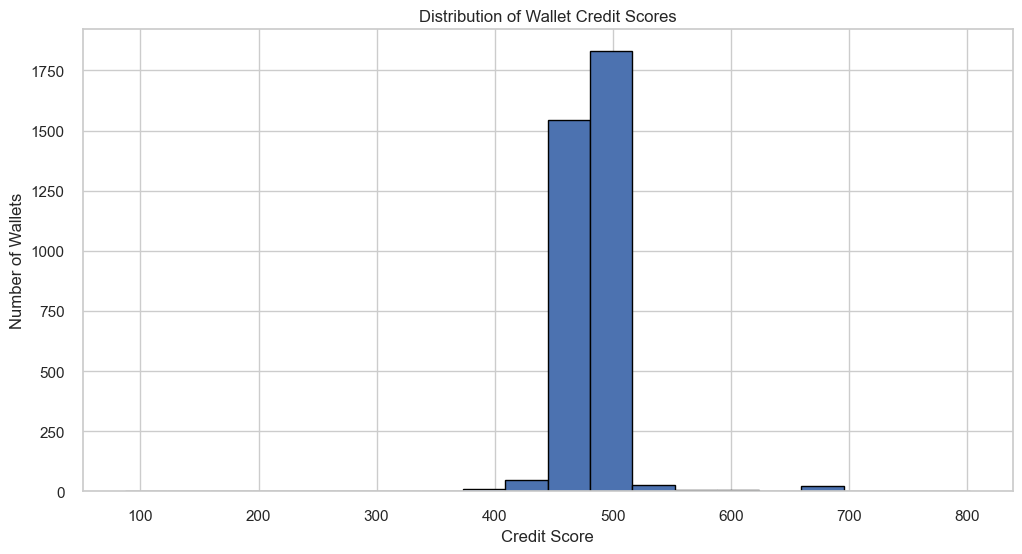

Score Range Distribution:
--------------------------------------------------
[0, 100): 1 wallets
[100, 200): 1 wallets
[200, 300): 2 wallets
[300, 400): 9 wallets
[400, 500): 3356 wallets
[500, 600): 100 wallets
[600, 700): 25 wallets
[700, 800): 2 wallets
[800, 900): 1 wallets
[900, 1000): 0 wallets

Behavior Patterns by Score Range:
--------------------------------------------------

Low Scores (0-300):
total_transactions        1.322500e+02
unique_actions            4.750000e+00
avg_amount                7.120857e+19
std_amount                1.569373e+20
max_amount                7.661570e+20
avg_time_between_txns     8.536530e+04
liquidation_count         1.600000e+01
deposit_borrow_ratio      1.013165e+00
deposit_ratio             2.859330e-01
redeemunderlying_ratio    1.164779e-01
borrow_ratio              2.922440e-01
repay_ratio               9.098575e-02
liquidationcall_ratio     2.143594e-01
dtype: float64

Medium Scores (300-700):
total_transactions        2.837880e+01
uniq

In [26]:
# Generate scores for all wallets
wallet_scores = model.predict(X_scaled)

# Create DataFrame with wallet addresses and scores
scores_df = pd.DataFrame({
    'wallet': X_scaled.index,
    'credit_score': wallet_scores
})

# Ensure scores are within 0-1000 range
scores_df['credit_score'] = scores_df['credit_score'].clip(0, 1000)

# Save scores to file
scores_df.to_csv('wallet_credit_scores.csv', index=False)

# Analyze score distribution
plt.figure(figsize=(12, 6))
plt.hist(scores_df['credit_score'], bins=20, edgecolor='black')
plt.title('Distribution of Wallet Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Number of Wallets')
plt.grid(True)
plt.show()

# Calculate score range distribution
ranges = list(range(0, 1001, 100))
score_ranges = pd.cut(scores_df['credit_score'], ranges, right=False)
range_distribution = score_ranges.value_counts().sort_index()

print("Score Range Distribution:")
print("-" * 50)
for interval, count in range_distribution.items():
    print(f"{interval}: {count} wallets")

# Analyze behavior patterns in different score ranges
def analyze_score_range(scores_df, features_df, min_score, max_score):
    wallets = scores_df[
        (scores_df['credit_score'] >= min_score) & 
        (scores_df['credit_score'] < max_score)
    ]['wallet']
    return features_df.loc[wallets].mean()

print("\nBehavior Patterns by Score Range:")
print("-" * 50)
print("\nLow Scores (0-300):")
print(analyze_score_range(scores_df, wallet_features, 0, 300))
print("\nMedium Scores (300-700):")
print(analyze_score_range(scores_df, wallet_features, 300, 700))
print("\nHigh Scores (700-1000):")
print(analyze_score_range(scores_df, wallet_features, 700, 1000))